
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E04_logistic_regression.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Logistic regression exercises 

---
These are introductory exercises in Machine learning with focus in **logistic regression**

<p class = "alert alert-info" role="alert"><b>Note</b> that sometimes you don't get exactly the same answer as I get, but it doesn't neccessarily mean it is wrong. Could be some parameters, randomization, that we have different. Also very important is that in the future there won't be any answer sheets, use your skills in data analysis, mathematics and statistics to back up your work.</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. Iris flower dataset (*)

In the whole exercise, we will work with the famous Iris flower dataset, which was collected in 1936 by Ronald Fisher, a statistician and biologist. Use the ```datasets``` module from scikit-learn to load the iris dataset. 

&nbsp; a) Check keys on the loaded data and check what the different values for each key are.

&nbsp; b) Now insert the data into a DataFrame. 

&nbsp; c) Do some EDA to get an understanding of the dataset. 

&nbsp; d) Make a correlation heatmap to see how each feature is correlated to each other. What do the numbers mean?

&nbsp; e) Make a boxplot. The points outside of the boxplot are statistically calculated outliers using Tukey's rule for boxplot. 

&nbsp; f) Now remove the outliers in data. (**)

- Lower bound outlier: $Q_1 - 1.5\cdot IQR$
- Upper bound outlier: $Q_3 + 1.5\cdot IQR$

where $Q_1$ is the 1st quartile or 25 percentile, $Q_3$ is the 3rd quartile or 75 percentile and $IQR = Q_3-Q_1$ is the interquartile range. 

<details>

<summary>Hint</summary>

a) For DESCR key you need to print it.

f) Dataframes has a quantile method.  

</details>

<details>

<summary>Answer</summary>

b) 

|    |   sepal length (cm) |   sepal width (cm) |   petal length (cm) |   petal width (cm) |   species | specie_name   |
|---:|--------------------:|-------------------:|--------------------:|-------------------:|----------:|:--------------|
|  0 |                 5.1 |                3.5 |                 1.4 |                0.2 |         0 | setosa        |
|  1 |                 4.9 |                3   |                 1.4 |                0.2 |         0 | setosa        |
|  2 |                 4.7 |                3.2 |                 1.3 |                0.2 |         0 | setosa        |
|  3 |                 4.6 |                3.1 |                 1.5 |                0.2 |         0 | setosa        |
|  4 |                 5   |                3.6 |                 1.4 |                0.2 |         0 | setosa        |

c) When you do describe, remove species as its statistical values are meaningless. 

|                   |    mean |      std |   min |   25% |   50% |   75% |   max |
|:------------------|--------:|---------:|------:|------:|------:|------:|------:|
| sepal length (cm) | 5.84333 | 0.828066 |   4.3 |   5.1 |  5.8  |   6.4 |   7.9 |
| sepal width (cm)  | 3.05733 | 0.435866 |   2   |   2.8 |  3    |   3.3 |   4.4 |
| petal length (cm) | 3.758   | 1.7653   |   1   |   1.6 |  4.35 |   5.1 |   6.9 |
| petal width (cm)  | 1.19933 | 0.762238 |   0.1 |   0.3 |  1.3  |   1.8 |   2.5 |


<img src = "../assets/pairplot_iris.png" height=300>

Do more EDA than I show here. 

d) Correlation heatmap

<img src = "../assets/Correlation_iris.png" height=300>

The closer the value is to 1 between two features, the more positively linear relationships between them. The closer the value is to -1 the more negatively linear relationships between them. 

e) 

<img src = "../assets/boxplot_iris.png" height=200>

f)
Outlier rows are: [13, 15, 22, 23, 24, 41, 43, 44, 98, 106, 117, 119, 131]

value counts:

|            |   specie_name |
|:-----------|--------------:|
| versicolor |            49 |
| virginica  |            46 |
| setosa     |            42 |

</details>

---

In [278]:
from sklearn import datasets
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

iris = datasets.load_iris()



In [279]:
print(iris.keys())
print(iris.feature_names)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [280]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [282]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


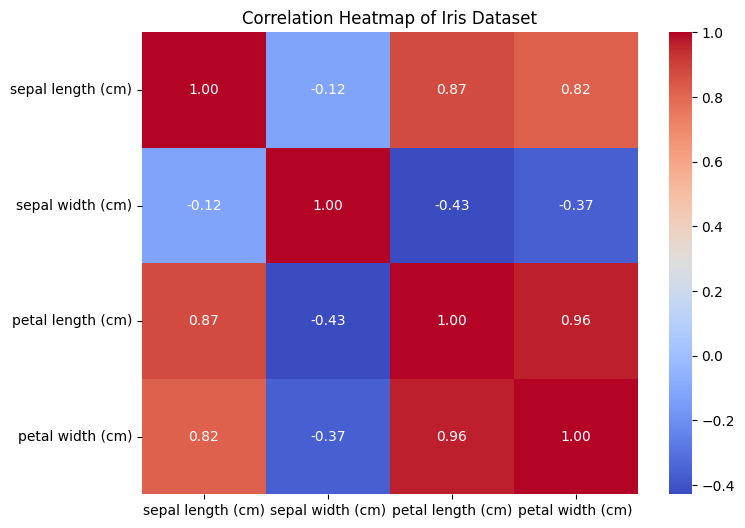

In [283]:
correlation_matrix = df.corr()


plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Iris Dataset")
plt.show()

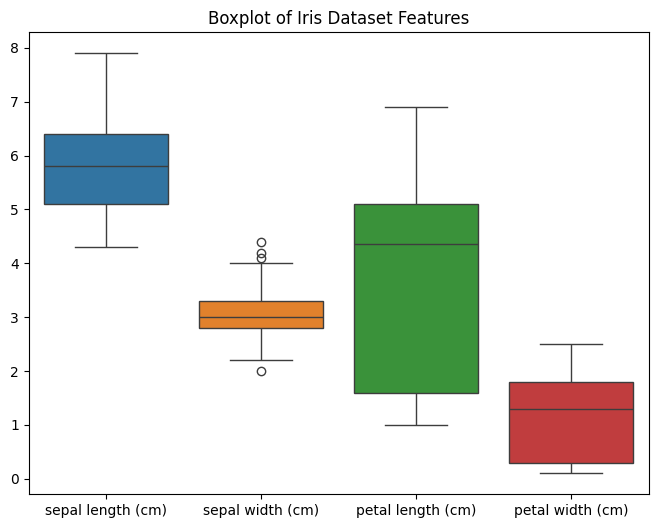

In [284]:

plt.figure(figsize=(8,6))
sns.boxplot(data=df)
plt.title("Boxplot of Iris Dataset Features")
plt.show()


In [285]:

df_cleaned = df


for col in df_cleaned.columns:  
    # Beräknar den första kvartilen (25:e percentilen), vilket motsvarar den nedre gränsen för den "normala" datan
    Q1 = df_cleaned[col].quantile(0.25)  
    
    # Beräknar den tredje kvartilen (75:e percentilen), vilket motsvarar den övre gränsen för den "normala" datan
    Q3 = df_cleaned[col].quantile(0.75)  
    
    # Beräknar interkvartilavståndet (IQR), vilket är skillnaden mellan Q3 och Q1.
    # Detta mäter spridningen av de mellersta 50% av datan.
    IQR = Q3 - Q1  

    # Definierar den nedre gränsen för outliers.
    # Om ett värde är mindre än detta anses det vara en outlier.
    lower_bound = Q1 - 1.5 * IQR  
    
    # Definierar den övre gränsen för outliers.
    # Om ett värde är större än detta anses det vara en outlier.
    upper_bound = Q3 + 1.5 * IQR  

    # Filtrerar bort rader där värdet i den aktuella kolumnen är en outlier
    # Behåller endast rader där värdet ligger inom de beräknade gränserna.
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]



print(f"Antal rader före filtrering: {df.shape[0]}")
print(f"Antal rader efter filtrering: {df_cleaned.shape[0]}")


Antal rader före filtrering: 150
Antal rader efter filtrering: 146


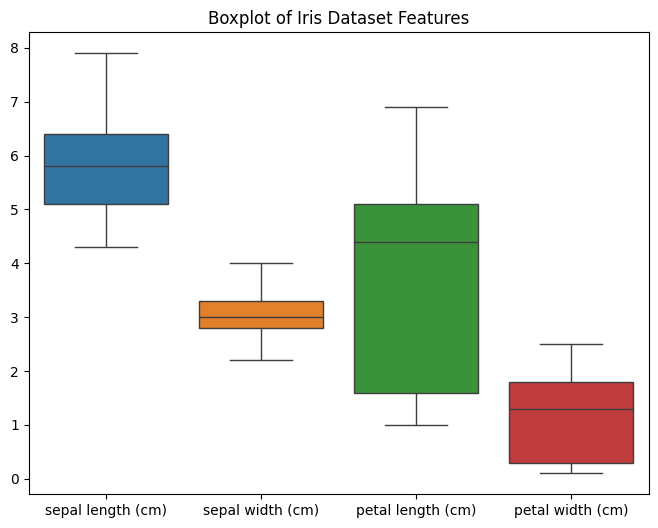

In [286]:

plt.figure(figsize=(8,6))
sns.boxplot(data=df_cleaned)
plt.title("Boxplot of Iris Dataset Features")
plt.show()


## 1. Split and scale data (*)

Do train|test split and scale the data using feature standardization, I used default test size 0.33 and random state 42. Check the mean and standard deviation on training and test data. 

---

In [287]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)




train_mean = np.mean(scaled_X_train, axis=0)
train_std = np.std(scaled_X_train, axis=0)


test_mean = np.mean(scaled_X_test, axis=0)
test_std = np.std(scaled_X_test, axis=0)


print("Training Data - Mean:", train_mean)
print("Training Data - Standard Deviation:", train_std)

print("Test Data - Mean:", test_mean)
print("Test Data - Standard Deviation:", test_std)




Training Data - Mean: [ 1.70530257e-15 -2.43249865e-15 -1.93178806e-16 -1.46549439e-16]
Training Data - Standard Deviation: [1. 1. 1. 1.]
Test Data - Mean: [ 0.10226315  0.33248356 -0.10072548 -0.07935823]
Test Data - Standard Deviation: [0.97502743 1.0795702  1.05127856 1.06216748]


## 2. Classify with logistic regression (*)

Use k-folded cross-validation with logistic regression to find suitable hyperparameters and model. Check the documentation to see which parameters that can be chosen through cross-validation. Check the models parameters and see what it has chosen. 

<details>

<summary>Answer</summary>

weights: 

```py
array([[-1.33033256,  1.35076961, -2.26169407, -2.07715072],
       [ 0.40073538, -0.28598722, -0.58388865, -0.7782766 ],
       [ 0.67977172, -0.81485664,  3.09503329,  3.10542664]])
```

$\ell_1$-ratio:

```py
array([0.2, 0.2, 0.2])
```


<img src = "../assets/pairplot_iris.png" height=300>

Do more EDA than I show here. 

d) Correlation heatmap

<img src = "../assets/Correlation_iris.png" height=300>

The closer the value is to 1 between two features, the more positively linear relationships between them. The closer the value is to -1 the more negatively linear relationships between them. 

e) 

<img src = "../assets/boxplot_iris.png" height=200>

f)
Outlier rows are: [13, 15, 22, 23, 24, 41, 43, 44, 98, 106, 117, 119, 131]

value counts:

|            |   specie_name |
|:-----------|--------------:|
| versicolor |            49 |
| virginica  |            46 |
| setosa     |            42 |

</details>

---

In [288]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV



# max_iter = max iterations, dvs ifall modellen når *konvergens* innan den når max_iter så slutar den "tidigt" per automatik. 
# Detta är för att de förändringar som går att göra mellan iterationerna blir för små för att ha betydelse
model = LogisticRegression(max_iter=10000)

# C = regleringsstyrka;
#   * Lågt C (0.01, 0.1) → Starkare reglering (mer begränsning på modellens koefficienter)
#   * Högt C (10) → Svagare reglering (modellen kan anpassa sig mer fritt)

# Penalty bestämmer vilken regleringsmetod vi ska använda;
#   * penalty='l1' → Lasso-reglering (vissa koefficienter kan bli exakt 0 → funktioner tas bort (feature selection)). Lasso är mer specialiserad än Ridge.
#   * penalty='l2' → Ridge-reglering (mjukare straff → inga koefficienter blir exakt 0, men små blir ännu mindre). Ridge är mer jack-of-all-trades.

# Solver = optimeringsalgoritm som används för att hitta bästa möjliga modellparametrar.
# Olika "solvers" fungerar bättre för olika typer av data och straff (penalty).
#   * liblinear → Fungerar bra för små dataset och stödjer både L1 och L2.
#   * saga → Fungerar bättre för stora dataset och stödjer både L1 och L2.

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],  
    'solver': ['liblinear', 'saga'] 
}

# GridSearchCV är ett verktyg för att automatiskt testa olika hyperparametrar och hitta den bästa kombinationen.
# Den testar alla möjliga kombinationer av param_grid (t.ex. C=0.1 med L1 och liblinear, C=10 med L2 och saga, osv.).

# k-folded: k = siffran i "cv=k", så t.ex "cv=5".
# Då blir t.ex cv=5 en 5-folded cross-validation. 

# cv = 5: cross-validation, dvs att för varje kombination delar den in datan i 5 delar och testar modellen 5 gånger på olika delar av datan.
# Detta innebär att modellen tränas på 4 av delarna och testas sedan på den 5:e. 
# Detta upprepas sedan 5 gånger, så att varje del får vara "testdata" en gång. 
# Den modell som får bäst scoring, i detta fall på accuracy, "vinner".
# Accuracy =  andel rätt klassificerade exempel.


grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(scaled_X_train, y_train)

print("Bästa hyperparametrar:", grid_search.best_params_)
print("Bästa modellens accuracy:", grid_search.best_score_)



Bästa hyperparametrar: {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}
Bästa modellens accuracy: 0.9400000000000001


## 3. Evaluate model (*)

Make a prediction on the testing data. 

&nbsp; a) Check manually the first 10 values of $y_{test}$ against your prediction. 

&nbsp; b) Plot a confusion matrix. Can you see which predictions the model have mispredicted?

&nbsp; c) Print a classification report 

<details>

<summary>Answer</summary>


b) 

<img src = "../assets/confusion_matrix_iris.png" height=300>



c) 

Classification report 

```py
          precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.94      0.97        16
           2       0.94      1.00      0.97        16

    accuracy                           0.98        46
   macro avg       0.98      0.98      0.98        46
weighted avg       0.98      0.98      0.98        46
```






</details>

---

In [289]:
# a
model.fit(scaled_X_train, y_train)  
y_pred = model.predict(scaled_X_test) 

print("Första 10 verkliga y_test:", y_test[:10])
print("Första 10 prediktioner y_pred:", y_pred[:10])
print(f"Är y_test[:10] och y_pred[:10] identiska? {y_test[:10] == y_pred[:10]}")

Första 10 verkliga y_test: [1 0 2 1 1 0 1 2 1 1]
Första 10 prediktioner y_pred: [1 0 2 1 1 0 1 2 1 1]
Är y_test[:10] och y_pred[:10] identiska? [ True  True  True  True  True  True  True  True  True  True]


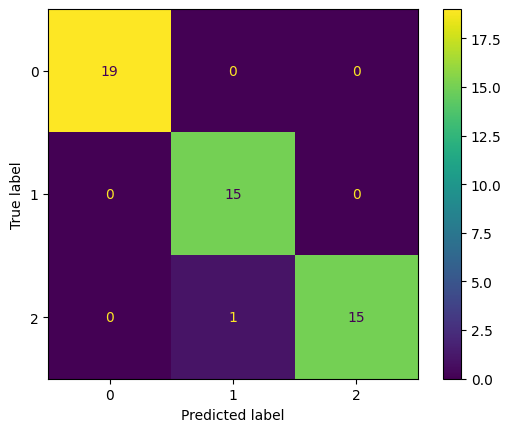

In [290]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# b

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
displ = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
displ.plot()

Only one prediction was off (predicted 1, true value was 2)!

In [291]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



## 4. $k$-folded cross-validation for evaluation (**)

To be more robust in reporting the results, you should report the results as $\mu_{score}$, i.e. average score through a k-folded cross-validation. Report the score for precision, recall, f1-score for each label and overall accuracy. Do the cross-validation manually using for statement. 

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Skapar en "K-Fold cross-validation instans"
# n_splits=5 → Datan delas in i 5 delar (folds), där varje del får vara testdata en gång.
kf = KFold(n_splits=5)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []


for train_index, test_index in kf.split(X):
    
    # Här delar jag upp datan likt K-fold-cv, så i 5 olika delar. 
    # .iloc används för att kunna använda DataFrame-variabler
    X_train_fold = X.iloc[train_index] 
    X_test_fold = X.iloc[test_index]
    y_train_fold = y[train_index] 
    y_test_fold = y[test_index]


    model.fit(X_train_fold, y_train_fold)
    

    y_pred_fold = model.predict(X_test_fold)

    # Här så beräknas och lagras accuracy, precision, recall och F1-score för denna fold (loop)
    accuracy_scores.append(accuracy_score(y_test_fold, y_pred_fold))

    # Precision = Andel av de positiva förutsägelserna som var korrekta
    # Recall = Andel av de verkliga positiva exemplen som hittades av modellen
    # F1-score = Kombination av precision och recall
    # "macro" → Beräknar medelvärdet för alla klasser
    # zero_division=1 → Undviker varningar genom att sätta recall till 1 om en klass saknas i testsetet
    precision_scores.append(precision_score(y_test_fold, y_pred_fold, average="macro", zero_division=1))
    recall_scores.append(recall_score(y_test_fold, y_pred_fold, average="macro", zero_division=1))
    f1_scores.append(f1_score(y_test_fold, y_pred_fold, average="macro"))

# Genomsnittlig prestanda över alla folds
mean_accuracy = np.mean(accuracy_scores)
mean_precision = np.mean(precision_scores)
mean_recall = np.mean(recall_scores)
mean_f1 = np.mean(f1_scores)

# De genomsnittliga resultaten (μ-score)
print(f"Genomsnittlig Accuracy: {mean_accuracy:.2f}") 
print(f"Genomsnittlig Precision: {mean_precision:.2f}")  
print(f"Genomsnittlig Recall: {mean_recall:.2f}")  
print(f"Genomsnittlig F1-score: {mean_f1:.2f}") 


Genomsnittlig Accuracy: 0.93
Genomsnittlig Precision: 0.78
Genomsnittlig Recall: 0.96
Genomsnittlig F1-score: 0.77


---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---